# Multilabel Classification with Logistic Regression and Evaluation Metrics

In this notebook, we'll:

Use a multilabel dataset.
* Implement Logistic Regression for multilabel classification.
* Address any class imbalance if necessary.
* Utilize appropriate evaluation metrics for multilabel classification.
* Perform cross-validation and compute cross-validated metrics.

# Introduction


**Multilabel classification** involves assigning each instance to one or more classes. This is different from multiclass classification, where each instance is assigned to one and only one class.

**Objective:** Build a Logistic Regression classifier to predict multiple labels for each instance and evaluate the model using appropriate multilabel metrics.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    hamming_loss,
    accuracy_score,
    classification_report,
    label_ranking_average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


# Generate and Explore the Data



Since multilabel datasets can be hard to find and load, we'll use scikit-learn's `make_multilabel_classification` to generate a synthetic dataset suitable for multilabel classification.

### Generate the Dataset


In [2]:
# Generate a synthetic multilabel dataset
X, Y = make_multilabel_classification(n_samples=1000, n_features=20, n_classes=5,
                                      n_labels=2, allow_unlabeled=False, random_state=42)

- **n_samples**: Number of samples.
- **n_features**: Number of features.
- **n_classes**: Number of possible labels.
- **n_labels**: Average number of labels per instance.
- **allow_unlabeled**: If `False`, all samples have at least one label.


### Explore the Dataset

In [3]:
# Convert to DataFrame for easier exploration
X = pd.DataFrame(X)
Y = pd.DataFrame(Y, columns=[f'Label_{i}' for i in range(1, 6)])

# Display the first five rows of features
X.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,3.0,0.0,2.0,2.0,2.0,8.0,3.0,2.0,5.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,6.0,5.0,0.0,2.0
1,3.0,5.0,2.0,3.0,3.0,3.0,1.0,1.0,4.0,1.0,1.0,4.0,2.0,8.0,4.0,3.0,2.0,6.0,2.0,0.0
2,3.0,2.0,3.0,1.0,0.0,5.0,3.0,2.0,2.0,7.0,2.0,2.0,2.0,4.0,1.0,0.0,6.0,6.0,3.0,3.0
3,1.0,0.0,1.0,6.0,6.0,1.0,4.0,1.0,2.0,7.0,8.0,2.0,5.0,5.0,3.0,2.0,0.0,0.0,3.0,0.0
4,3.0,6.0,2.0,1.0,1.0,2.0,5.0,1.0,4.0,5.0,2.0,1.0,5.0,1.0,5.0,7.0,3.0,5.0,4.0,1.0


In [4]:
# Display the first five rows of labels
display(Y.head())

,Label_1,Label_2,Label_3,Label_4,Label_5
0,0,0,0,1,0
1,1,1,1,0,0
2,0,0,1,1,0
3,1,0,0,0,0
4,1,0,1,0,0


### Check Label Distribution


In [5]:
# Sum of each label
label_counts = Y.sum()
print('Label Counts:\n', label_counts)

Label Counts:
 Label_1    369
Label_2    635
Label_3    563
Label_4    478
Label_5    194
dtype: int64


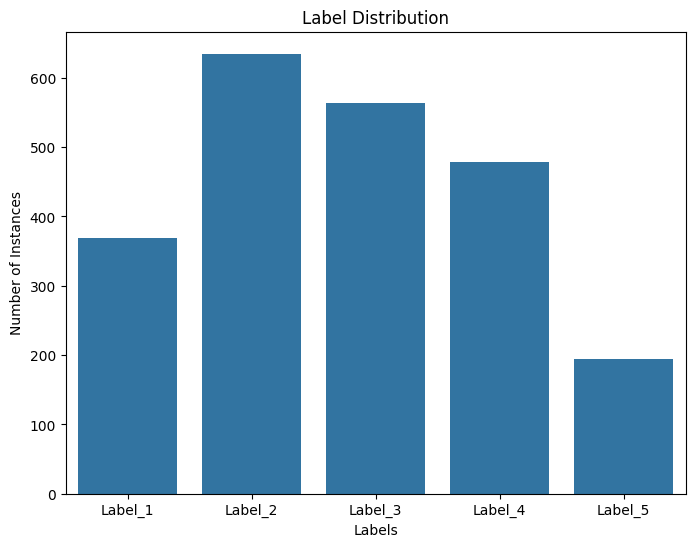

In [6]:
# Plot the label distribution
plt.figure(figsize=(8,6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Label Distribution')
plt.xlabel('Labels')
plt.ylabel('Number of Instances')
plt.show()

**Observation**: The labels may not be perfectly balanced, but for this synthetic dataset, the imbalance is typically not severe.


## Data Preprocessing

### Split into Training and Testing Sets

In [7]:
# Split features and labels into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

### Feature Scaling

In [8]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modeling with Logistic Regression

In multilabel classification, we can use **One-vs-Rest (OvR)** strategy, where a binary classifier is fit for each label.

### Initialize and Train the Model

In [9]:
# Initialize the Logistic Regression model
model = OneVsRestClassifier(
    LogisticRegression(solver='lbfgs', max_iter=100, random_state=42)
)

# Train the model
model.fit(X_train, Y_train)

OneVsRestClassifier(estimator=LogisticRegression(random_state=42))

### Predictions on the Test Set

In [10]:
# Predictions
Y_pred = model.predict(X_test)

## Model Evaluation

Evaluating multilabel classifiers requires specialized metrics.

### Hamming Loss

The **Hamming Loss** is the fraction of labels that are incorrectly predicted.

In [11]:
from sklearn.metrics import hamming_loss

# Calculate Hamming Loss
hl = hamming_loss(Y_test, Y_pred)
print('Hamming Loss:', hl)

Hamming Loss: 0.178


**Interpretation**: Lower Hamming Loss indicates better performance.

### Subset Accuracy

The **Subset Accuracy** is the fraction of samples that have all their labels correctly predicted.

In [12]:
from sklearn.metrics import accuracy_score

# Calculate Subset Accuracy
subset_acc = accuracy_score(Y_test, Y_pred)
print('Subset Accuracy:', subset_acc)

Subset Accuracy: 0.4


**Interpretation**: This is a strict metric; the prediction for a sample is considered correct only if all its predicted labels match the true labels.

### Classification Report

We can generate a classification report for each label.

In [13]:
print('Classification Report:\n')
print(classification_report(Y_test, Y_pred, target_names=Y.columns))

Classification Report:

              precision    recall  f1-score   support

     Label_1       0.82      0.68      0.74        79
     Label_2       0.88      0.92      0.90       130
     Label_3       0.80      0.79      0.80       104
     Label_4       0.79      0.82      0.81        96
     Label_5       0.68      0.36      0.47        42

   micro avg       0.82      0.77      0.80       451
   macro avg       0.80      0.71      0.74       451
weighted avg       0.81      0.77      0.79       451
 samples avg       0.84      0.86      0.81       451



### Label Ranking Average Precision (LRAP)

**LRAP** measures how well the classifier ranks the true labels.

In [14]:
from sklearn.metrics import label_ranking_average_precision_score

# Predict probabilities
Y_pred_proba = model.predict_proba(X_test)

# Calculate LRAP
lrap = label_ranking_average_precision_score(Y_test.values, Y_pred_proba)
print('Label Ranking Average Precision (LRAP):', lrap)

Label Ranking Average Precision (LRAP): 0.9689722222222223


**Interpretation**: LRAP ranges from 0 to 1, with higher scores indicating better performance.

## Cross-Validated Metrics

We'll perform cross-validation to get a more robust evaluation.

### Cross-Validation Setup

In [15]:
# Initialize KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Cross-Validated Hamming Loss

In [16]:
from sklearn.model_selection import cross_val_score

# Cross-validated Hamming Loss
from sklearn.metrics import make_scorer

hl_scores = cross_val_score(
    model, X, Y, cv=kf, scoring=make_scorer(hamming_loss,greater_is_better=False), n_jobs=-1
)
print('Cross-Validated Hamming Loss:', -hl_scores)
print('Mean Hamming Loss:', -hl_scores.mean())

Cross-Validated Hamming Loss: [0.177 0.166 0.169 0.169 0.171]
Mean Hamming Loss: 0.17040000000000002


### Cross-Validated Subset Accuracy

In [17]:
# Cross-validated Subset Accuracy
subset_acc_scores = cross_val_score(
    model, X, Y, cv=kf, scoring='accuracy', n_jobs=-1
)
print('Cross-Validated Subset Accuracy:', subset_acc_scores)
print('Mean Subset Accuracy:', subset_acc_scores.mean())

Cross-Validated Subset Accuracy: [0.405 0.455 0.405 0.4   0.465]
Mean Subset Accuracy: 0.426


### Cross-Validated LRAP

In [18]:
# Define a custom scorer for LRAP
from sklearn.metrics import make_scorer

lrap_scorer = make_scorer(label_ranking_average_precision_score)

# Cross-validated LRAP
lrap_scores = cross_val_score(
    model, X, Y, cv=kf, scoring=lrap_scorer, n_jobs=-1
)
print('Cross-Validated LRAP:', lrap_scores)
print('Mean LRAP:', lrap_scores.mean())

Cross-Validated LRAP: [0.8230625  0.84400694 0.82028472 0.81409028 0.83470833]
Mean LRAP: 0.8272305555555555


## Conclusion



- **Multilabel Classification**: Successfully built a Logistic Regression model using One-vs-Rest strategy to handle multilabel classification.
- **Evaluation Metrics**:
    - **Hamming Loss**: Provided an average misclassification rate over all labels.
    - **Subset Accuracy**: Offered a strict metric where only exact matches are considered correct.
    - **Label Ranking Average Precision (LRAP)**: Measured the ability of the classifier to rank true labels higher than false ones.
- **Cross-Validation**: Provided robust estimates of model performance across different splits of the data.

**Key Takeaways**:

- Multilabel classification requires specialized models and evaluation metrics.
- Logistic Regression with One-vs-Rest strategy is effective for multilabel problems.
- Evaluation metrics like Hamming Loss, Subset Accuracy, and LRAP provide insights into different aspects of model performance.
- Cross-validation enhances the reliability of performance estimates.

---

**Encouragement**:

By exploring multilabel classification, you've broadened your understanding of machine learning tasks that involve more complex label structures. Keep experimenting with different datasets and models to continue enhancing your machine learning skills!